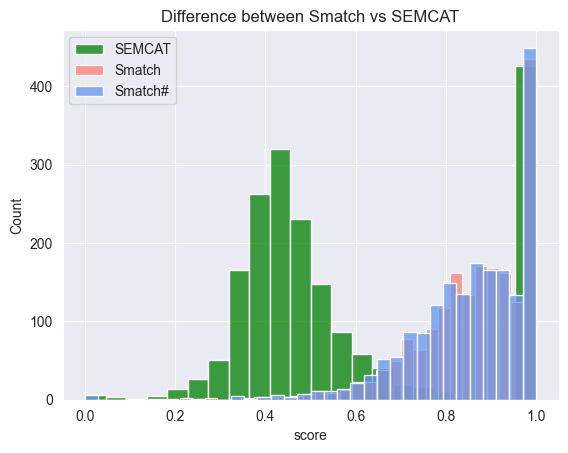

In [2]:
import seaborn
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('result/per-item.csv')

# SEMCAT
selected_metrics = ['ESMATCH++mac', 'RoSE3-99']
weights = {'ESMATCH++mac': 0.5, 'RoSE3-99': 0.5}

selected_data = data[data['metric'].isin(selected_metrics)].copy()

grouped = selected_data.apply(lambda row: row['score'] * weights[row['metric']], axis=1).groupby(
    [selected_data['name'], selected_data['item']]).sum().reset_index()

new_rows = []
for _, row in grouped.iterrows():
    new_row = {}
    new_row['name'] = row['name']
    new_row['metric'] = 'SEMCAT'
    new_row['item'] = row['item']
    new_row['score'] = row[0]
    new_rows.append(new_row)

data = pd.concat([data, pd.DataFrame(new_rows)], axis=0).drop(columns = 'Unnamed: 0', axis=1)

# Test start
v3_data = data[data['name'].str.startswith('v3.0_')]

seaborn.histplot(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='SEMCAT')], x='score', color='green', label='SEMCAT')
seaborn.histplot(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='SMATCH')], x='score', color='salmon', label='Smatch')
seaborn.histplot(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='ESMATCH++mac')], x='score', color='cornflowerblue', label='Smatch#')

plt.legend(loc='upper left')
plt.title('Difference between Smatch vs SEMCAT')
plt.show()

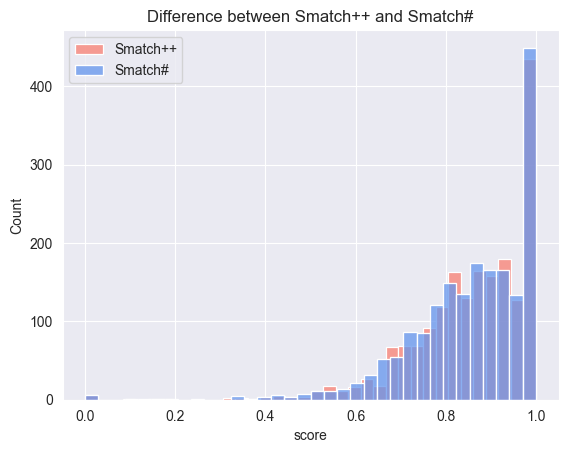

In [3]:
seaborn.histplot(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='SMATCH++mac')], x='score', color='salmon', label='Smatch++')
seaborn.histplot(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='ESMATCH++mac')], x='score', color='cornflowerblue', label='Smatch#')

plt.legend(loc='upper left')
plt.title('Difference between Smatch++ and Smatch#')
plt.show()

Total same score items for alpha 0: 1111
Total larger score items for alpha 0: 188
Total smaller score items for alpha 0: 599
Total same score item for alpha 1: 388
Total larger score items for alpha 1: 39
Total smaller score items for alpha 1: 1471


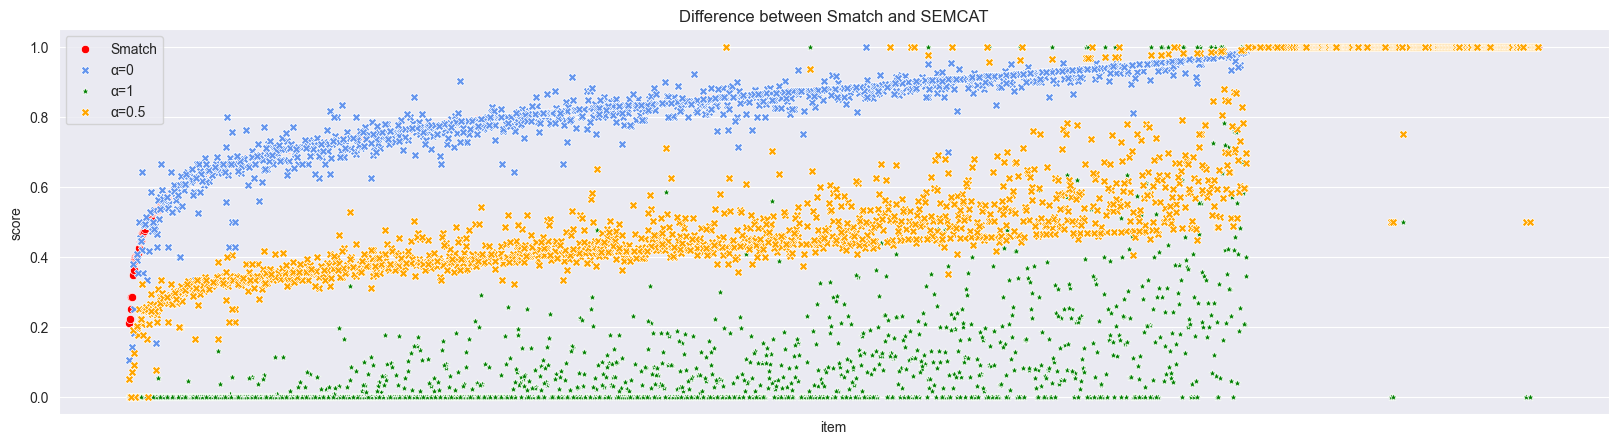

In [4]:
plt.figure(figsize=(20, 5))

sorted_whole_smatch = v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='SMATCH')].sort_values(by='score')

smatch_v3 = list(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='SMATCH')]['score'])
ssharp_v3 = list(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='ESMATCH++mac')]['score'])
semcat_v3 = list(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='RoSE3-99')]['score'])

s_count_v3 = 0
b_count_v3 = 0
l_count_v3 = 0

for i in range(0, len(smatch_v3)):
    if smatch_v3[i] == ssharp_v3[i]:
        s_count_v3+=1
    elif smatch_v3[i] < ssharp_v3[i]:
        b_count_v3+=1
    elif smatch_v3[i] > ssharp_v3[i]:
        l_count_v3+=1

print(f"Total same score items for alpha 0: {s_count_v3}")
print(f"Total larger score items for alpha 0: {b_count_v3}")
print(f"Total smaller score items for alpha 0: {l_count_v3}")

s_count_v3 = 0
b_count_v3 = 0
l_count_v3 = 0

for i in range(0, len(smatch_v3)):
    if smatch_v3[i] == semcat_v3[i]:
        s_count_v3+=1
    elif smatch_v3[i] < semcat_v3[i]:
        b_count_v3+=1
    elif smatch_v3[i] > semcat_v3[i]:
        l_count_v3+=1
        
print(f"Total same score item for alpha 1: {s_count_v3}")
print(f"Total larger score items for alpha 1: {b_count_v3}")
print(f"Total smaller score items for alpha 1: {l_count_v3}")


seaborn.scatterplot(sorted_whole_smatch, x='item', y='score', color='red', label='Smatch')
seaborn.scatterplot(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='ESMATCH++mac')], x='item', y='score', color='cornflowerblue', marker = 'X', label='α=0')
# seaborn.scatterplot(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='ESMATCH')], x='item', y='score', color='cornflowerblue', label='Smatch#')
seaborn.scatterplot(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='RoSE3-99')], x='item', y='score', color='green', marker = '*', label='α=1')
seaborn.scatterplot(v3_data[(v3_data['name']=='v3.0_AMRBART-v2-3.0')&(v3_data['metric']=='SEMCAT')], x='item', y='score', marker= 'X', color='orange', label='α=0.5')


ax = plt.gca()
ax.axes.xaxis.set_ticks([])

plt.title('Difference between Smatch and SEMCAT')
plt.show()

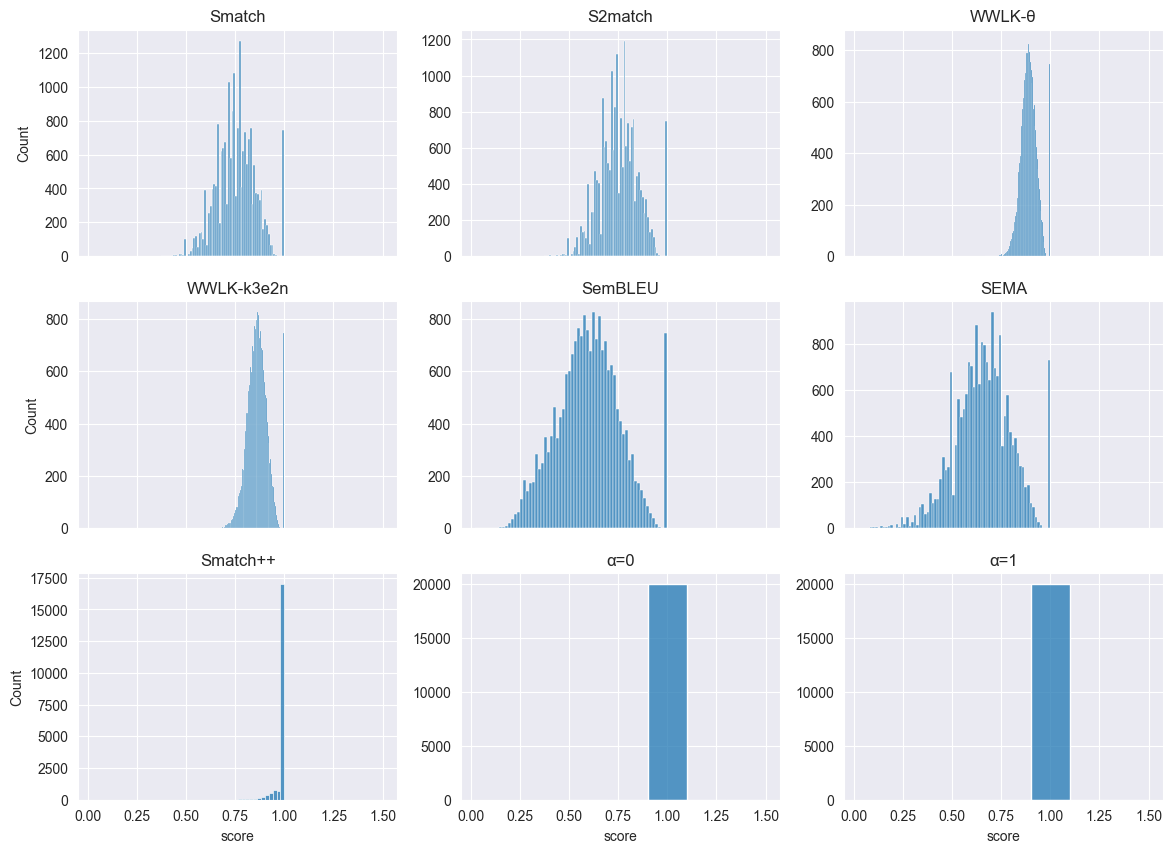

In [5]:
eq_data = data[data['name'].str.startswith('eq_')]

f, axes = plt.subplots(3, 3, figsize=(14, 10), sharex=True)

seaborn.histplot(eq_data[(eq_data['name']=='eq_reify')&(eq_data['metric']=='SMATCH')], x='score', ax=axes[0,0]).set_title('Smatch')
seaborn.histplot(eq_data[(eq_data['name']=='eq_reify')&(eq_data['metric']=='S2MATCH')], x='score', ax=axes[0,1]).set(title='S2match', ylabel='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_reify')&(eq_data['metric']=='WWLK-theta')], x='score', ax=axes[0,2]).set(title='WWLK-θ', ylabel='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_reify')&(eq_data['metric']=='WWLK-k3e2n')], x='score', ax=axes[1,0]).set_title('WWLK-k3e2n')
seaborn.histplot(eq_data[(eq_data['name']=='eq_reify')&(eq_data['metric']=='SEMBLEU')], x='score', ax=axes[1,1]).set(title='SemBLEU', ylabel ='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_reify')&(eq_data['metric']=='SEMA')], x='score', ax=axes[1,2]).set(title='SEMA', ylabel='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_reify')&(eq_data['metric']=='SMATCH++mac')], x='score', ax=axes[2,0]).set_title('Smatch++')
seaborn.histplot(eq_data[(eq_data['name']=='eq_reify')&(eq_data['metric']=='ESMATCH++mac')], x='score', ax=axes[2,1], bins=5).set(title='α=0', ylabel ='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_reify')&(eq_data['metric']=='RoSE3-99')], x='score', ax=axes[2,2], bins=5).set(title='α=1', ylabel='')
plt.show()

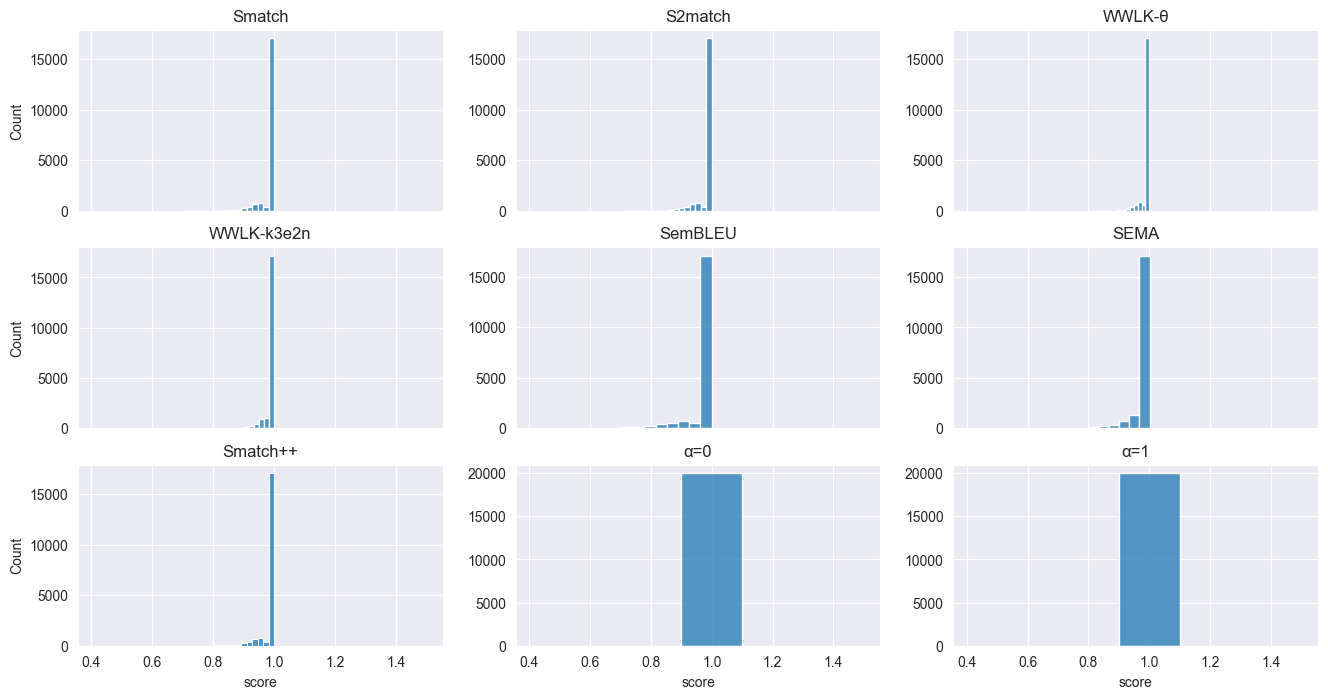

In [6]:
f, axes = plt.subplots(3, 3, figsize=(16, 8), sharex=True)

seaborn.histplot(eq_data[(eq_data['name']=='eq_dereify')&(eq_data['metric']=='SMATCH')], x='score', ax=axes[0,0]).set_title('Smatch')
seaborn.histplot(eq_data[(eq_data['name']=='eq_dereify')&(eq_data['metric']=='S2MATCH')], x='score', ax=axes[0,1]).set(title='S2match', ylabel='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_dereify')&(eq_data['metric']=='WWLK-theta')], x='score', ax=axes[0,2]).set(title='WWLK-θ', ylabel='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_dereify')&(eq_data['metric']=='WWLK-k3e2n')], x='score', ax=axes[1,0]).set_title('WWLK-k3e2n')
seaborn.histplot(eq_data[(eq_data['name']=='eq_dereify')&(eq_data['metric']=='SEMBLEU')], x='score', ax=axes[1,1]).set(title='SemBLEU', ylabel='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_dereify')&(eq_data['metric']=='SEMA')], x='score', ax=axes[1,2]).set(title='SEMA', ylabel='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_dereify')&(eq_data['metric']=='SMATCH++mac')], x='score', ax=axes[2,0]).set_title('Smatch++')
seaborn.histplot(eq_data[(eq_data['name']=='eq_dereify')&(eq_data['metric']=='ESMATCH++mac')], x='score', ax=axes[2,1], bins=5).set(title='α=0', ylabel='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_dereify')&(eq_data['metric']=='RoSE3-99')], x='score', ax=axes[2,2], bins=5).set(title='α=1', ylabel='')
plt.show()

ignoring epigraph data for duplicate triple: ('d', ':month', '11')


Total: 1898
Total reify-applied sentences: 258
Total same score on reify items on alpha 0: 9
Total same score on reify items on alpha 1: 3


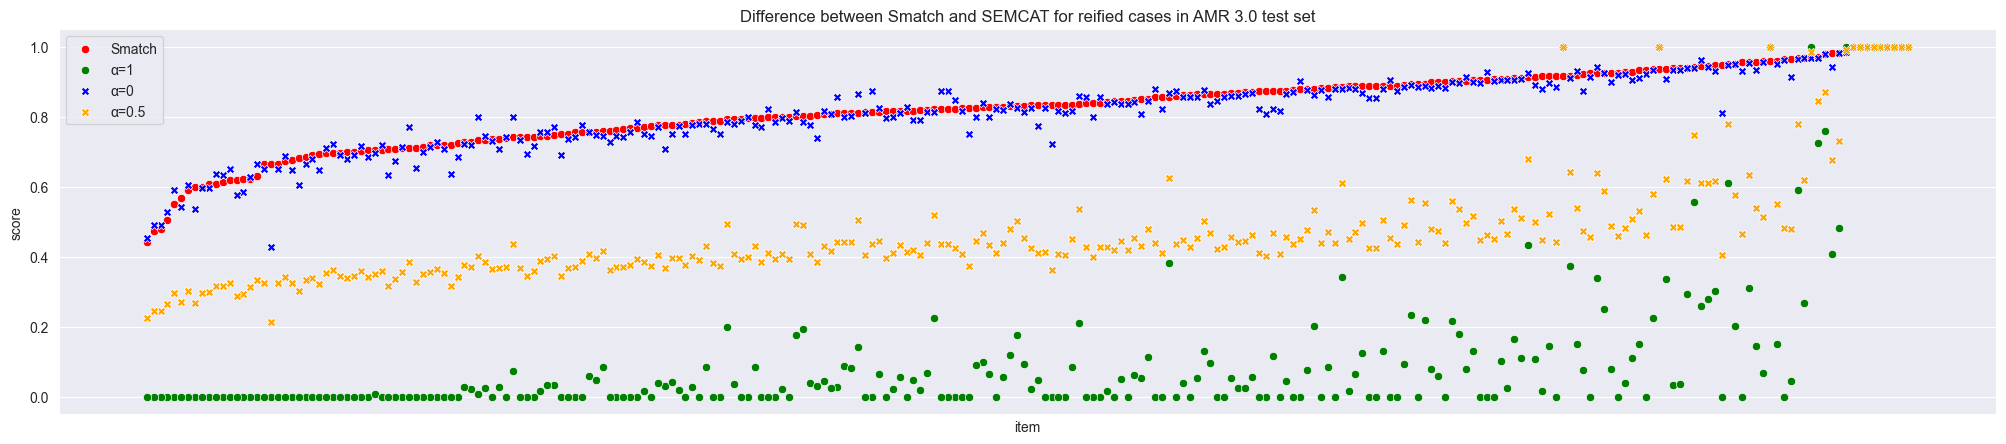

In [7]:
import penman
from penman.codec import format
from penman.layout import interpret, reconfigure
from penman.models.amr import model
from penman.transform import dereify_edges

count = 0
reify = []
v3_depths = []

def get_max_depth(graph):
    max_depth = 0
    tree = reconfigure(graph, top=graph.top, model=model)
    for branch in tree.walk():
        if branch[0][0] > max_depth:
            max_depth = branch[0][0]
    return max_depth

def dereify(graph, data):
    global count
    global reify
    dereified_graph = dereify_edges(graph, model=model)
    if graph != dereified_graph:
        count+=1
        reify.append(data.index(graph))
        # print(f"this graph has applied reification: {data.index(graph)}")
    # Convert it into a tree and rearrange
    return dereified_graph

data_3 = penman.load('/mnt/sda/Code_local/RoSE/experiment/resources/amr-annotations/amr3.0-test.txt', model=model, encoding='utf-8')
print(f"Total: {len(data_3)}")
for item in data_3:
    dereify(item, data_3)
    v3_depths.append(get_max_depth(item))
    
print(f"Total reify-applied sentences: {count}")

ids = []

for idx in reify:
    ids.append(data_3[idx].metadata['id'])

reify_data = v3_data[v3_data['item'].isin(ids)]

plt.figure(figsize=(25, 5))

sorted_smatch_3 = reify_data[(reify_data['name']=='v3.0_AMRBART-v2-3.0')&(reify_data['metric']=='SMATCH')].sort_values(by='score')

d_count_v3 = 0

seaborn.scatterplot(sorted_smatch_3, x='item', y='score', color='red', label='Smatch')
seaborn.scatterplot(reify_data[(reify_data['name']=='v3.0_AMRBART-v2-3.0')&(reify_data['metric']=='RoSE3-99')], x='item', y='score', color='green', label='α=1')
seaborn.scatterplot(reify_data[(reify_data['name']=='v3.0_AMRBART-v2-3.0')&(reify_data['metric']=='ESMATCH++mac')], x='item', y='score', marker= 'X', color='blue', label='α=0')
seaborn.scatterplot(reify_data[(reify_data['name']=='v3.0_AMRBART-v2-3.0')&(reify_data['metric']=='SEMCAT')], x='item', y='score', marker= 'X', color='orange', label='α=0.5')

smatch_v3 = list(reify_data[(reify_data['name']=='v3.0_AMRBART-v2-3.0')&(reify_data['metric']=='SMATCH')]['score'])
ssharp_v3 = list(reify_data[(reify_data['name']=='v3.0_AMRBART-v2-3.0')&(reify_data['metric']=='ESMATCH++mac')]['score'])
cose_v3 = list(reify_data[(reify_data['name']=='v3.0_AMRBART-v2-3.0')&(reify_data['metric']=='RoSE3-99')]['score'])

d_count_v3 = 0
c_count_v3 = 0
for i in range(0, len(smatch_v3)):
    if smatch_v3[i] == ssharp_v3[i]:
        d_count_v3+=1
    if smatch_v3[i] == semcat_v3[i]:
        c_count_v3+=1
        
print(f"Total same score on reify items on alpha 0: {d_count_v3}")
print(f"Total same score on reify items on alpha 1: {c_count_v3}")

ax = plt.gca()
ax.axes.xaxis.set_ticks([])

plt.title('Difference between Smatch and SEMCAT for reified cases in AMR 3.0 test set')
plt.show()

ignoring epigraph data for duplicate triple: ('d', ':month', '11')


Total: 1371
Total reify-applied sentences: 181
Total same score items: 791
Total same score reify items on alpha 0: 7
Total same score reify items on alpha 1: 7


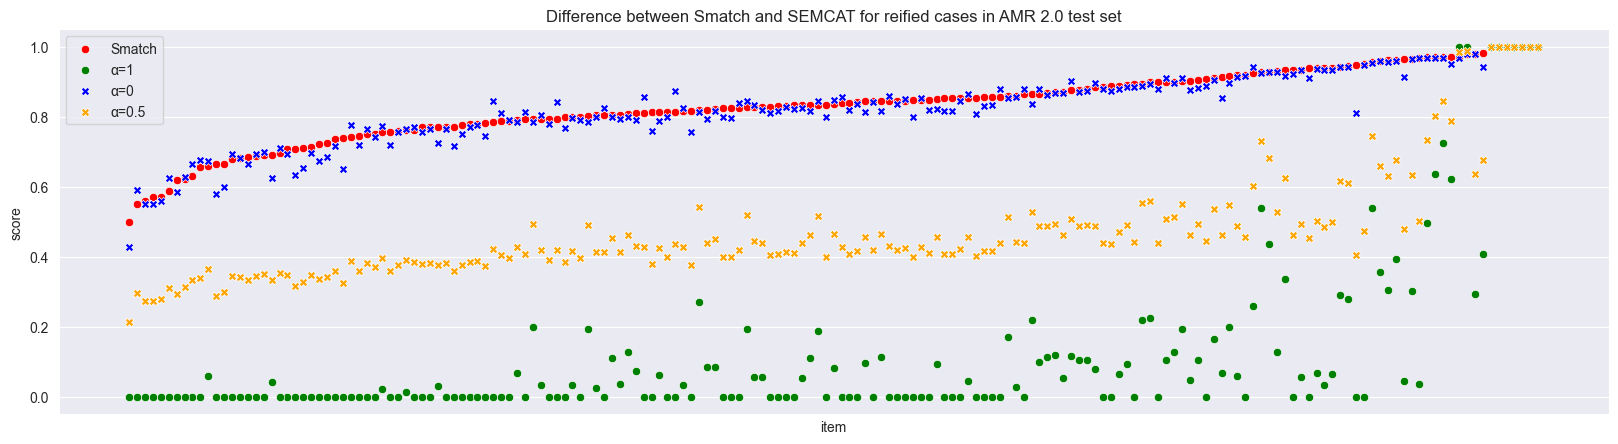

In [8]:
count = 0
reify = []
v2_depths = []

data_2 = penman.load('/mnt/sda/Code_local/RoSE/experiment/resources/amr-annotations/amr2.0-test.txt', model=model, encoding='utf-8')
print(f"Total: {len(data_2)}")

for item in data_2:
    dereify(item, data_2)
    v2_depths.append(get_max_depth(item))

print(f"Total reify-applied sentences: {count}")

ids = []

for idx in reify:
    ids.append(data_2[idx].metadata['id'])

v2_data = data[data['name'].str.startswith('v2.0_')]
reify_data = v2_data[v2_data['item'].isin(ids)]

plt.figure(figsize=(20, 5))

# current = pd.concat([reify_data[(reify_data['name']=='v2.0_AMRBART-v2-2.0')&(reify_data['metric']=='SMATCH')], 
#                     reify_data[(reify_data['name']=='v2.0_AMRBART-v2-2.0')&(reify_data['metric']=='CoSE')]], axis=0)

# seaborn.barplot(current, hue='metric', x='item', y='score')

sorted_smatch_2 = reify_data[(reify_data['name']=='v2.0_AMRBART-v2-2.0')&(reify_data['metric']=='SMATCH')].sort_values(by='score')

smatch_v2 = list(v2_data[(v2_data['name']=='v2.0_AMRBART-v2-2.0')&(v2_data['metric']=='SMATCH')]['score'])
ssharp_v2 = list(v2_data[(v2_data['name']=='v2.0_AMRBART-v2-2.0')&(v2_data['metric']=='ESMATCH++mac')]['score'])

d_count_v2 = 0
for i in range(0, len(smatch_v2)):
    if smatch_v2[i] == ssharp_v2[i]:
        d_count_v2+=1
print(f"Total same score items: {d_count_v2}")

seaborn.scatterplot(sorted_smatch_2, x='item', y='score', color='red', label='Smatch')
seaborn.scatterplot(reify_data[(reify_data['name']=='v2.0_AMRBART-v2-2.0')&(reify_data['metric']=='RoSE3-99')], x='item', y='score', color='green', label='α=1')
seaborn.scatterplot(reify_data[(reify_data['name']=='v2.0_AMRBART-v2-2.0')&(reify_data['metric']=='ESMATCH++mac')], x='item', y='score', marker= 'X', color='blue', label='α=0')
seaborn.scatterplot(reify_data[(reify_data['name']=='v2.0_AMRBART-v2-2.0')&(reify_data['metric']=='SEMCAT')], x='item', y='score', marker= 'X', color='orange', label='α=0.5')

smatch_v2 = list(reify_data[(reify_data['name']=='v2.0_AMRBART-v2-2.0')&(reify_data['metric']=='SMATCH')]['score'])
ssharp_v2 = list(reify_data[(reify_data['name']=='v2.0_AMRBART-v2-2.0')&(reify_data['metric']=='ESMATCH++mac')]['score'])
cose_v2 = list(reify_data[(reify_data['name']=='v2.0_AMRBART-v2-2.0')&(reify_data['metric']=='RoSE3-99')]['score'])

d_count_v2 = 0
c_count_v2 = 0
for i in range(0, len(smatch_v2)):
    if smatch_v2[i] == ssharp_v2[i]:
        d_count_v2+=1
    if smatch_v2[i] == cose_v2[i]:
        c_count_v2+=1
        
print(f"Total same score reify items on alpha 0: {d_count_v2}")
print(f"Total same score reify items on alpha 1: {c_count_v2}")

ax = plt.gca()
ax.axes.xaxis.set_ticks([])

plt.title('Difference between Smatch and SEMCAT for reified cases in AMR 2.0 test set')
plt.show()

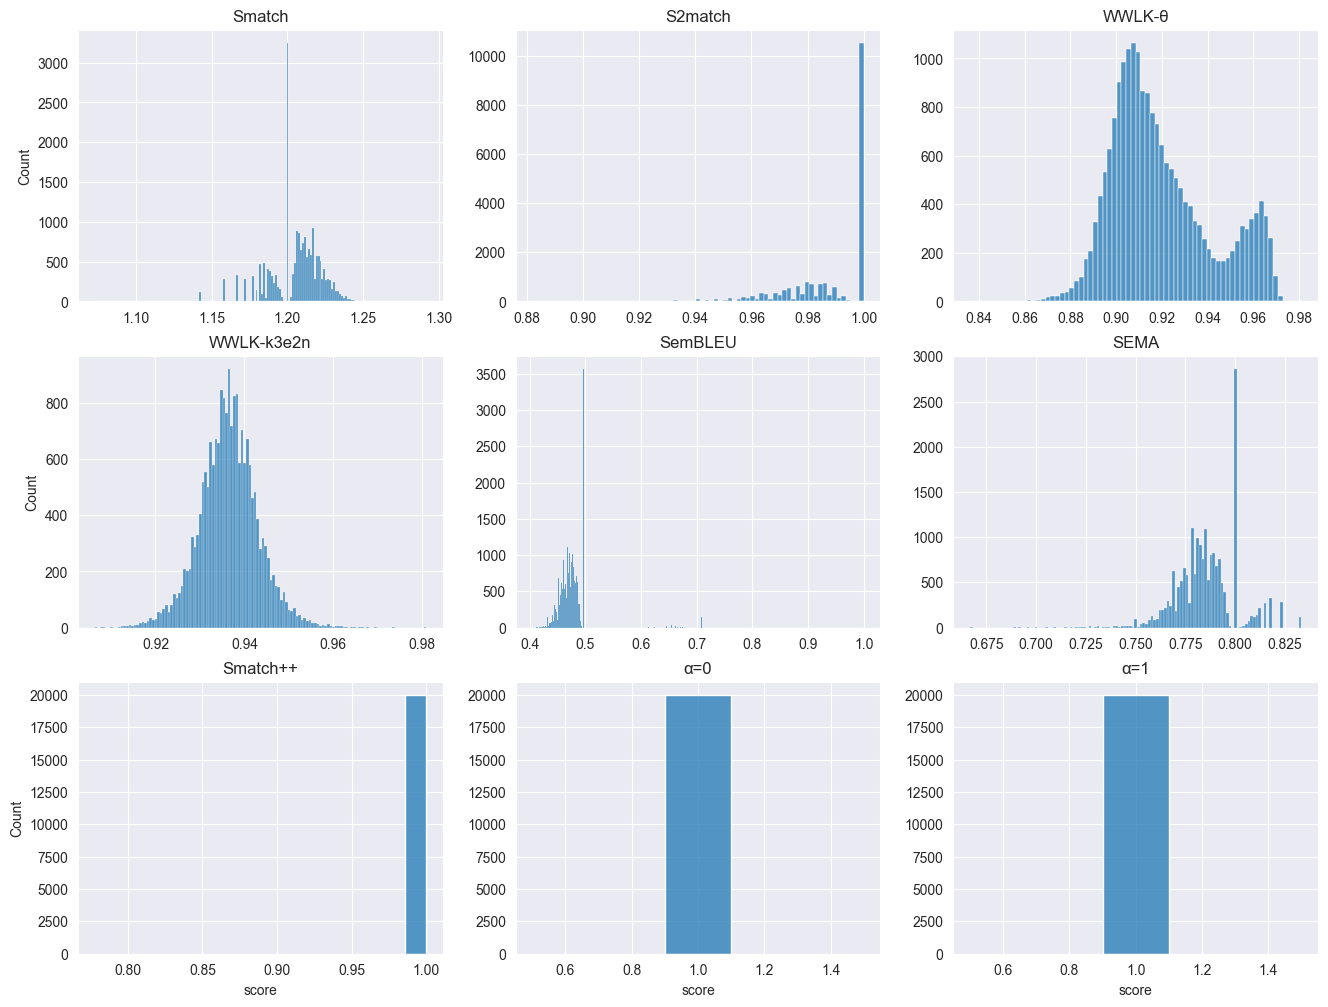

In [9]:
f, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=False)

seaborn.histplot(eq_data[(eq_data['name']=='eq_duplicate')&(eq_data['metric']=='SMATCH')], x='score', ax=axes[0,0]).set(title = 'Smatch', xlabel='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_duplicate')&(eq_data['metric']=='S2MATCH')], x='score', ax=axes[0,1]).set(title = 'S2match', xlabel ='', ylabel ='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_duplicate')&(eq_data['metric']=='WWLK-theta')], x='score', ax=axes[0,2]).set(title = 'WWLK-θ', xlabel ='', ylabel='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_duplicate')&(eq_data['metric']=='WWLK-k3e2n')], x='score', ax=axes[1,0]).set(title='WWLK-k3e2n', xlabel ='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_duplicate')&(eq_data['metric']=='SEMBLEU')], x='score', ax=axes[1,1]).set(title='SemBLEU', xlabel ='', ylabel ='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_duplicate')&(eq_data['metric']=='SEMA')], x='score', ax=axes[1,2]).set(title='SEMA', xlabel ='', ylabel='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_duplicate')&(eq_data['metric']=='SMATCH++mac')], x='score', ax=axes[2,0]).set_title('Smatch++')
seaborn.histplot(eq_data[(eq_data['name']=='eq_duplicate')&(eq_data['metric']=='ESMATCH++mac')], x='score', ax=axes[2,1], bins=5).set(title='α=0', ylabel ='')
seaborn.histplot(eq_data[(eq_data['name']=='eq_duplicate')&(eq_data['metric']=='RoSE3-99')], x='score', ax=axes[2,2], bins=5).set(title='α=1', ylabel='')
plt.show()

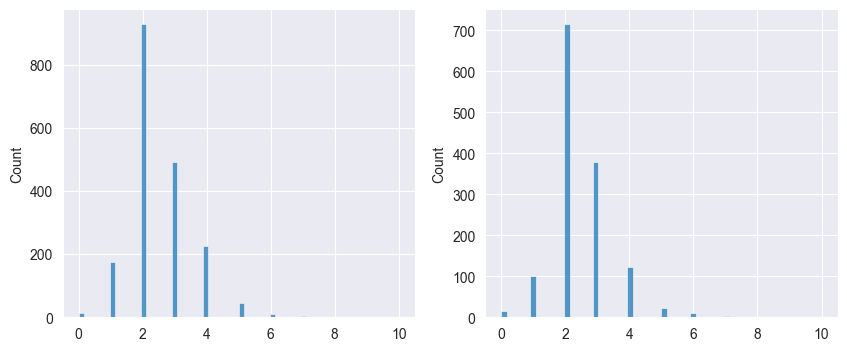

V3_Coverage: 0.8493150684931506
V2_Coverage: 0.8832968636032094


In [10]:
f, axes = plt.subplots(ncols=2, figsize=(10, 4), sharex=False)

seaborn.histplot(v3_depths, ax=axes[0])
seaborn.histplot(v2_depths, ax=axes[1])

plt.show()

v3_most = []
for d in v3_depths:
    if d < 4:
        v3_most.append(d)

v2_most = []
for d in v2_depths:
    if d < 4:
        v2_most.append(d)

print(f"V3_Coverage: {len(v3_most)/len(v3_depths)}")
print(f"V2_Coverage: {len(v2_most)/len(v2_depths)}")


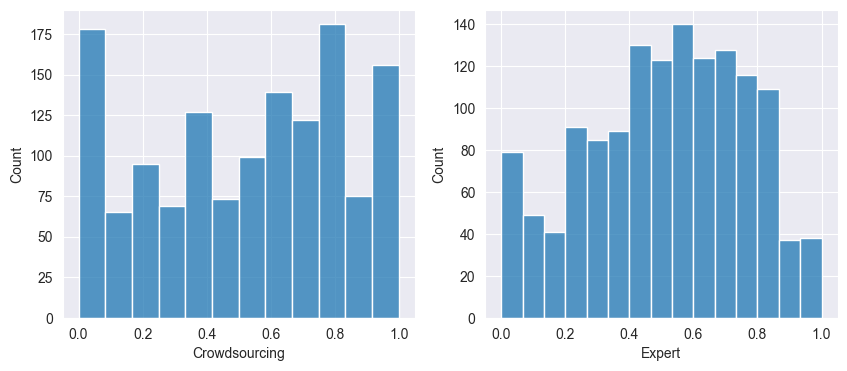

In [11]:
human = pd.read_excel('hyperparam.xlsx')

f, axes = plt.subplots(ncols=2, figsize=(10, 4), sharex=False)

seaborn.histplot(human['GENERAL']/5, ax=axes[0]).set(xlabel='Crowdsourcing')
seaborn.histplot(human['EXP'], ax=axes[1]).set(xlabel='Expert')

plt.show()


Max correlation with GENERAL is 0.59434441 at p = 0.1650
Max correlation with EXP is 0.77424064 at p = 0.0000
Max correlation with Average is GENERAL: 0.59425687 and EXP: 0.77397868 at p = 0.1020


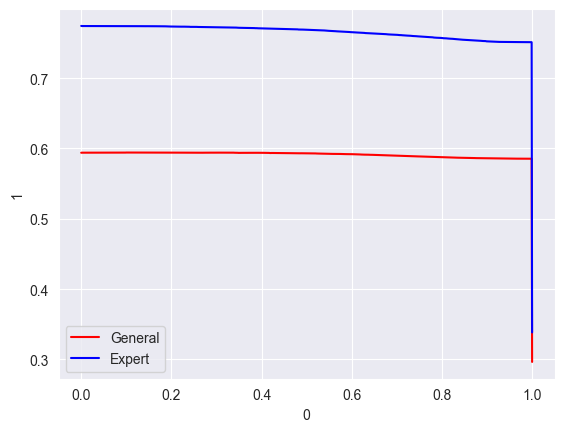

In [12]:
import scipy as sp
import numpy as np

p_values = np.arange(0, 1.001, 0.001)
results = []  

para_data = pd.read_excel('hyperparam.xlsx')

for p in p_values:
    para_data['SEMCAT'] = para_data['Smatch#']*(1-p) + para_data['Simplehash-3']*p
    correlation_gen = para_data['SEMCAT'].corr(para_data['GENERAL'], method = "spearman")
    correlation_exp = para_data['SEMCAT'].corr(para_data['EXP'], method = "spearman")

    # correlation_gen = human['CoSE'].corr(data['Human'])

    results.append((p, correlation_gen, correlation_exp))

# 이제 p 값과 그에 해당하는 상관계수를 출력합니다.
# for p, corr_gen, corr_exp in results: #, corr_exp in results:
    # print(f"p: {p:.4f}, Correlation with GENERAL: {corr_gen:.8f}, Correlation with EXP: {corr_exp:.8f}")

# 각 상관계수의 최대값과 그에 해당하는 p 값을 찾습니다.
max_corr_gen = max(results, key=lambda x: x[1])
max_corr_exp = max(results, key=lambda x: x[2])
max_corr_avg = max(results, key=lambda x: x[1]+x[2]/2)

print(f"\nMax correlation with GENERAL is {max_corr_gen[1]:.8f} at p = {max_corr_gen[0]:.4f}")
print(f"Max correlation with EXP is {max_corr_exp[2]:.8f} at p = {max_corr_exp[0]:.4f}")
print(f"Max correlation with Average is GENERAL: {max_corr_avg[1]:.8f} and EXP: {max_corr_avg[2]:.8f} at p = {max_corr_avg[0]:.4f}")

genline = pd.DataFrame([(p, corr_gen) for p, corr_gen, corr_exp in results])
expline = pd.DataFrame([(p, corr_exp) for p, corr_gen, corr_exp in results])

seaborn.lineplot(genline, color ='red', x=genline[0], y=genline[1], label='General')
seaborn.lineplot(expline, color ='blue', x=expline[0], y=expline[1], label='Expert')

plt.show()